 Principal Component Analysis and Multiclass Classification

## Main Goals

By the end of this assignment, you should be able to:

1. Implement PCA from scratch using NumPy.
2. Explain explained variance and cumulative explained variance.
3. Reconstruct data approximately using principal components.
4. Use PCA before a multiclass classifier.
5. Analyze the trade-off between dimensionality reduction and classification performance.

---



In [3]:

STUDENT1_NAME = "mustafa mürsel yeşildal"
STUDENT1_ID = "0708"

# Use the last four digits of your student ID as the seed.
# Example: if your student ID is 150210123, then RANDOM_SEED = 123
RANDOM_SEED = int(STUDENT1_ID[-4:])

assert STUDENT1_NAME != "", "Please enter your name."
assert STUDENT1_ID != "", "Please enter your student ID."
assert RANDOM_SEED is not None, "Please enter your random seed using the last four digits of your student ID."

print("Student 1:", STUDENT1_NAME)
print("Student ID 1:", STUDENT1_ID)

print("Random seed:", RANDOM_SEED)

Student 1: mustafa mürsel yeşildal
Student ID 1: 0708
Random seed: 708


## 1. Imports

Run the following cell. You may add additional imports if necessary, but you should not import `sklearn.decomposition.PCA`.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

np.random.seed(RANDOM_SEED)

## 2. Dataset Loading and Exploration

The dataset consists of 8 × 8 grayscale images of handwritten digits.

Each sample has:

- 64 input features
- One class label from 0 to 9

In [34]:
digits = load_digits()

X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Classes:", np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


### 2.1 Visualize Sample Images

Run the following cell to visualize a few images from the dataset.

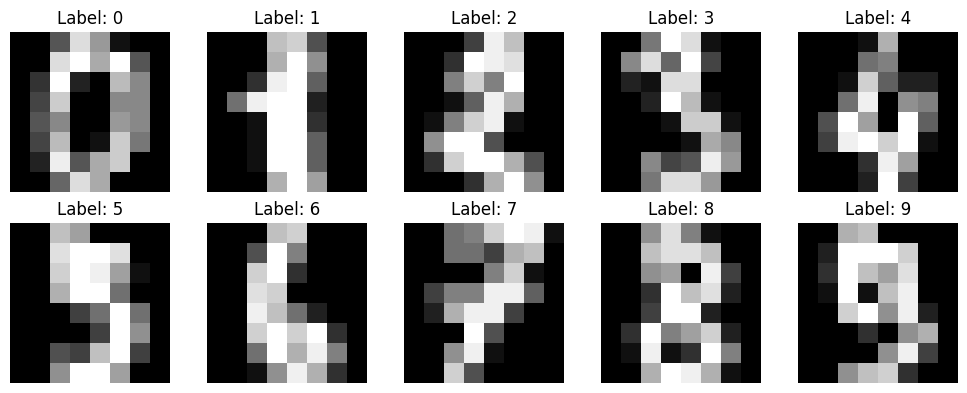

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()



1. What is the dimensionality of each input sample in this dataset?
2. Why can dimensionality reduction be useful for image-like data?
3. PCA is an unsupervised method. What does this mean?
4. Since PCA does not use labels, why can it still be used before a supervised classifier?




**Answer 1:**

EACH INPUT SAMPLE has a dimensionality of 64(8*8), which represents the total pixels in the image.DIMENSIONALITY REDUCTION is very useful for image-like data because it removes redundant pixels and noise, which helps the model run much faster. PCA is an unsupervised method because it only looks at the input features and does not need target labels to find patterns.WE USED BEFORE A SUPERVİSED CLASSİFİER BECAUSE it captures the most important variations in the data. By keeping only the essential information, it helps the classifier focus on the most significant features and avoid overfitting.

## 3. Train-Test Split and Standardization

Before applying PCA, we split the dataset into training and test sets.

We also standardize the features. PCA is sensitive to feature scale because it depends on variance.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (1347, 64)
Test set shape: (450, 64)


## 4. PCA from Scratch

In this section, you will implement PCA using NumPy.

You should not use `sklearn.decomposition.PCA`.

The main PCA steps are:

1. Center the data.
2. Compute principal directions using SVD or eigendecomposition.
3. Project the data onto selected principal components.
4. Optionally reconstruct the original data approximately.

---

### Implementation Task 1 — PCA Fitting Function

Complete the function below.

The function should return:

- `mean`: mean vector of the training data
- `components`: principal components with shape `(n_components, n_features)`
- `explained_variance`: explained variance values
- `explained_variance_ratio`: explained variance ratio values

Recommended approach: use `np.linalg.svd`.

**Points: 25**

In [37]:
def fit_pca(X, n_components):
    """
    Fit PCA on the given data.

    Parameters
    ----------
    X : np.ndarray
        Input data with shape (n_samples, n_features).
    n_components : int
        Number of principal components.

    Returns
    -------
    mean : np.ndarray
        Mean vector with shape (n_features,).
    components : np.ndarray
        Principal components with shape (n_components, n_features).
    explained_variance : np.ndarray
        Explained variance for each selected component.
    explained_variance_ratio : np.ndarray
        Explained variance ratio for each selected component.
    """

    # TODO: Get number of samples
    n_samples = X.shape[0]

    # TODO: Compute the mean of X
    mean = np.mean(X, axis=0)

    # TODO: Center the data
    X_centered = X - mean

    # TODO: Apply SVD
    # Hint:
    # U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # TODO: Select the first n_components rows of Vt as principal components
    components = Vt[:n_components, :]

    # TODO: Compute explained variance for all components
    # Formula:
    # explained_variance_all = (S ** 2) / (n_samples - 1)
    explained_variance_all = (S ** 2) / (n_samples - 1)

    # TODO: Compute explained variance ratio for all components
    explained_variance_ratio_all = explained_variance_all / np.sum(explained_variance_all)

    # TODO: Keep only the first n_components values
    explained_variance = explained_variance_all[:n_components]
    explained_variance_ratio = explained_variance_ratio_all[:n_components]

    return mean, components, explained_variance, explained_variance_ratio

### Implementation Task 2 — PCA Transform and Inverse Transform

Complete the following functions.

`transform_pca` projects data onto the PCA space.

`inverse_transform_pca` reconstructs data back into the original feature space.

**Points: 8**

In [38]:
def transform_pca(X, mean, components):
    """
    Project X onto PCA components.

    Parameters
    ----------
    X : np.ndarray
        Input data with shape (n_samples, n_features).
    mean : np.ndarray
        Mean vector with shape (n_features,).
    components : np.ndarray
        Principal components with shape (n_components, n_features).

    Returns
    -------
    X_projected : np.ndarray
        PCA-transformed data with shape (n_samples, n_components).
    """

    # TODO: Center X using the training mean
    X_centered = X - mean

    # TODO: Project data onto components
    # Multiply centered data by the transpose of the components matrix
    X_projected = np.dot(X_centered, components.T)

    return X_projected


def inverse_transform_pca(X_projected, mean, components):
    """
    Reconstruct data from PCA space.

    Parameters
    ----------
    X_projected : np.ndarray
        PCA-transformed data with shape (n_samples, n_components).
    mean : np.ndarray
        Mean vector with shape (n_features,).
    components : np.ndarray
        Principal components with shape (n_components, n_features).

    Returns
    -------
    X_reconstructed : np.ndarray
        Reconstructed data with shape (n_samples, n_features).
    """

    # TODO: Reconstruct the data
    # Project back to original feature space and add the mean back
    X_reconstructed = np.dot(X_projected, components) + mean

    return X_reconstructed

### 4.1 Test Your PCA Implementation

Run the following cell after completing your PCA functions.

If your implementation is correct, the assertions should pass.

In [39]:
n_components_test = 10

mean, components, explained_variance, explained_variance_ratio = fit_pca(
    X_train_scaled,
    n_components=n_components_test
)

X_train_pca = transform_pca(X_train_scaled, mean, components)
X_test_pca = transform_pca(X_test_scaled, mean, components)

print("Mean shape:", mean.shape)
print("Components shape:", components.shape)
print("Train PCA shape:", X_train_pca.shape)
print("Test PCA shape:", X_test_pca.shape)
print("Explained variance shape:", explained_variance.shape)
print("Explained variance ratio shape:", explained_variance_ratio.shape)
print("Total explained variance ratio:", explained_variance_ratio.sum())

assert mean.shape == (X_train_scaled.shape[1],)
assert components.shape == (n_components_test, X_train_scaled.shape[1])
assert X_train_pca.shape == (X_train_scaled.shape[0], n_components_test)
assert X_test_pca.shape == (X_test_scaled.shape[0], n_components_test)
assert explained_variance.shape == (n_components_test,)
assert explained_variance_ratio.shape == (n_components_test,)
assert np.all(explained_variance >= 0)
assert np.all(explained_variance_ratio >= 0)
assert explained_variance_ratio.sum() <= 1.0 + 1e-8

print("All tests passed.")

Mean shape: (64,)
Components shape: (10, 64)
Train PCA shape: (1347, 10)
Test PCA shape: (450, 10)
Explained variance shape: (10,)
Explained variance ratio shape: (10,)
Total explained variance ratio: 0.5890388602755268
All tests passed.


## 5. Explained Variance Analysis

The explained variance ratio tells us how much information each principal component captures.

In this section, you will analyze how many principal components are needed to preserve a desired amount of variance.

### Implementation Task 3A — Cumulative Explained Variance

Run the following cell and make sure that your PCA implementation correctly produces the cumulative explained variance curve and the component counts required for 80%, 90%, and 95% variance preservation.

**Points: 4**

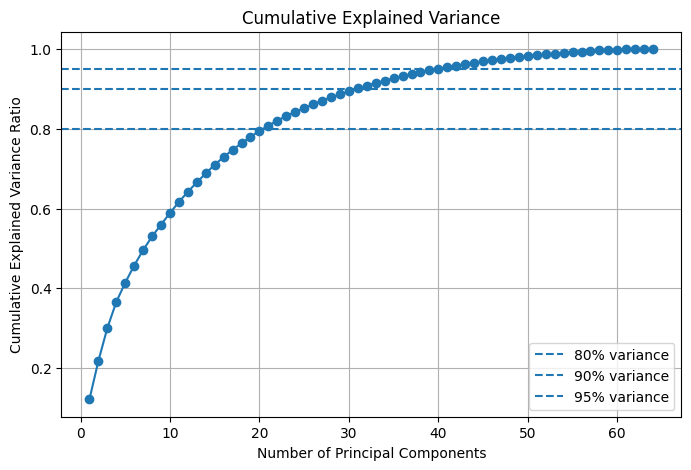

Components needed for at least 80% variance: 21
Components needed for at least 90% variance: 31
Components needed for at least 95% variance: 40


In [40]:
# Fit PCA with all possible components
max_components = X_train_scaled.shape[1]

mean_all, components_all, explained_variance_all, explained_variance_ratio_all = fit_pca(
    X_train_scaled,
    n_components=max_components
)

cumulative_explained_variance = np.cumsum(explained_variance_ratio_all)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, max_components + 1), cumulative_explained_variance, marker="o")
plt.axhline(y=0.80, linestyle="--", label="80% variance")
plt.axhline(y=0.90, linestyle="--", label="90% variance")
plt.axhline(y=0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

components_80 = np.argmax(cumulative_explained_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1

print("Components needed for at least 80% variance:", components_80)
print("Components needed for at least 90% variance:", components_90)
print("Components needed for at least 95% variance:", components_95)

## 6. Reconstruction from Principal Components

PCA can also be used to reconstruct an approximation of the original data.

In this section, you will reconstruct digit images using different numbers of principal components.

### Implementation Task 3B — Reconstruction Visualization

Complete the following cell.

You should:

1. Select one test sample using your random seed.
2. Fit PCA with different numbers of components.
3. Project the selected sample into PCA space.
4. Reconstruct the selected sample from PCA space.
5. Convert the reconstructed sample back to the original pixel scale.
6. Visualize the original image and the reconstructed images.

**Points: 5**

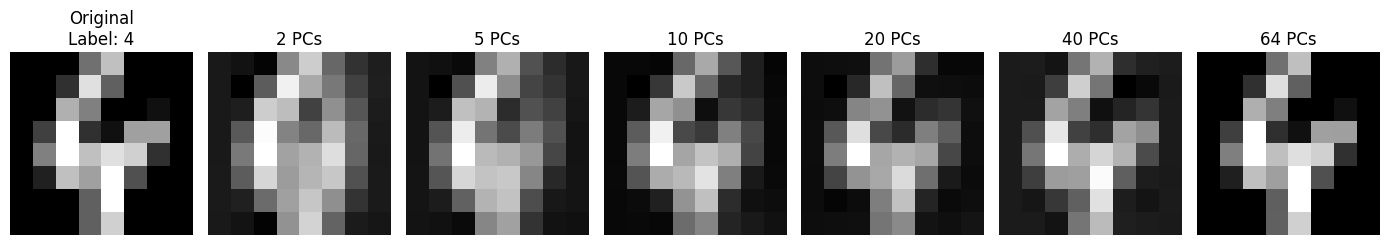

In [41]:
# TODO: Select one sample based on your random seed.
# Hint: use RANDOM_SEED modulo the number of test samples.
sample_index = RANDOM_SEED % X_test_scaled.shape[0]

# TODO: Define the component values that will be tested.
# Use the following values: 2, 5, 10, 20, 40, 64
component_values = [2, 5, 10, 20, 40, 64]

# TODO: Select the scaled test sample using sample_index.
# The shape should remain (1, n_features), not (n_features,).
# Slicing with [i:i+1] ensures the shape stays 2D
original_scaled = X_test_scaled[sample_index:sample_index+1] 

# TODO: Get the true label of the selected sample.
original_label = y_test[sample_index]

reconstructed_images = []

for n_comp in component_values:
    # TODO: Fit PCA on the scaled training data using n_comp components.
    mean_n, components_n, _, _ = fit_pca(X_train_scaled, n_comp)
    
    # TODO: Project the selected sample into PCA space.
    projected = transform_pca(original_scaled, mean_n, components_n)
    
    # TODO: Reconstruct the selected sample from PCA space.
    reconstructed_scaled = inverse_transform_pca(projected, mean_n, components_n)
    
    # TODO: Convert the reconstructed sample back to the original pixel scale.
    # Assuming 'scaler' is the variable name for your fitted StandardScaler/MinMaxScaler
    reconstructed_original_scale = scaler.inverse_transform(reconstructed_scaled)
    
    # TODO: Reshape the reconstructed sample into an 8 x 8 image and append it.
    reconstructed_images.append(reconstructed_original_scale.reshape(8, 8))

# TODO: Convert the original scaled sample back to the original pixel scale
# and reshape it into an 8 x 8 image.
original_image = scaler.inverse_transform(original_scaled).reshape(8, 8)


# The plotting code remains the same
fig, axes = plt.subplots(1, len(component_values) + 1, figsize=(14, 3))

axes[0].imshow(original_image, cmap="gray")
axes[0].set_title(f"Original\nLabel: {original_label}")
axes[0].axis("off")

for ax, img, n_comp in zip(axes[1:], reconstructed_images, component_values):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{n_comp} PCs")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Implementation Task 3C — Reconstruction Error

Complete and run the following cell.

For each number of components, compute the mean squared reconstruction error on the test set.

**Points: 3**

n_components | reconstruction_mse
----------------------------------------
           2 | 0.718662
           5 | 0.523996
          10 | 0.374604
          20 | 0.201508
          40 | 0.050935
          64 | 0.000000


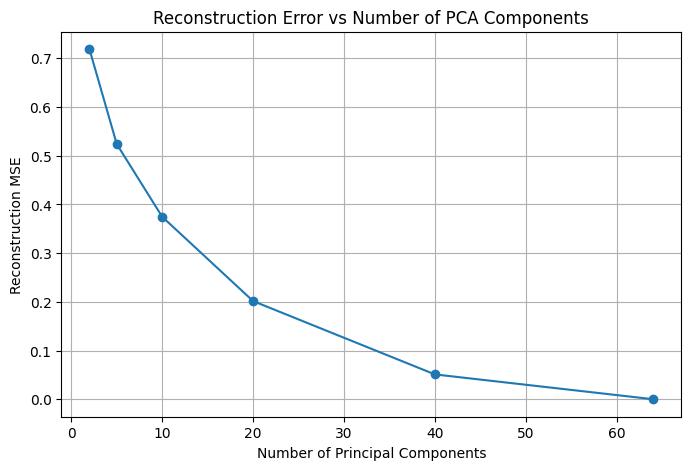

In [42]:
component_values = [2, 5, 10, 20, 40, 64]
reconstruction_errors = []

for n_comp in component_values:
    mean_n, components_n, _, _ = fit_pca(X_train_scaled, n_components=n_comp)
    
    # TODO: Project the test data
    X_test_projected = transform_pca(X_test_scaled, mean_n, components_n)
    
    # TODO: Reconstruct the test data
    X_test_reconstructed = inverse_transform_pca(X_test_projected, mean_n, components_n)
    
    # TODO: Compute mean squared reconstruction error
    mse = np.mean((X_test_scaled - X_test_reconstructed) ** 2)
    
    reconstruction_errors.append({
        "n_components": n_comp,
        "reconstruction_mse": mse
    })

print("n_components | reconstruction_mse")
print("-" * 40)

for result in reconstruction_errors:
    print(
        f"{result['n_components']:>12} | "
        f"{result['reconstruction_mse']:.6f}"
    )

plt.figure(figsize=(8, 5))
plt.plot(
    [r["n_components"] for r in reconstruction_errors],
    [r["reconstruction_mse"] for r in reconstruction_errors],
    marker="o"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of PCA Components")
plt.grid(True)
plt.show()




1. How many components are needed to preserve at least 80%, 90%, and 95% of the variance?
2. What happens to reconstruction quality as the number of components increases?
3. At approximately how many components does the digit become visually recognizable?
4. Does preserving more variance always mean preserving all class-discriminative information?



**Answer 2:**

1-)According to the Cumulative Explained Variance plot, we need 21 components to preserve 80% of the variance, 31 components to reach 90%, and 40 components to maintain 95%. This shows that we can represent most of the data's information using fewer than half of the original 64 dimensions.
2-)As the number of components increases, the reconstruction quality improves significantly. This is clearly supported by the Reconstruction Error plot, where the Mean Squared Error (MSE) drops from approximately 0.71 (with 2 PCs) to 0.05 (with 40 PCs), eventually reaching 0 when all 64 components are used. Visually, the images become sharper and much closer to the original.
3-)Looking at the Reconstructed Images, the digit starts to become recognizable around 10 components, though it is still quite blurry. By 20 components, which corresponds to roughly 80% variance, the shape of the "4" is clearly visible and easy to identify.
4-)Not necessarily. Variance just shows where the data spreads out the most, but "most spread" doesn't always mean "most useful." For example, if all your images have a very bright background, PCA might see that background as a "high variance" part and focus on it. However, the background doesn't help you tell the difference between a "3" and an "8." The tiny details that actually separate the classes might have low variance, so PCA might ignore them. In short, PCA finds the "loudest" patterns, but the classifier needs the "most meaningful" patterns, and they are not always the same thing.

## 7. Visualization Using the First Two Principal Components

In this section, you will project the training data onto the first two principal components and visualize the samples.

Each point represents one digit image.

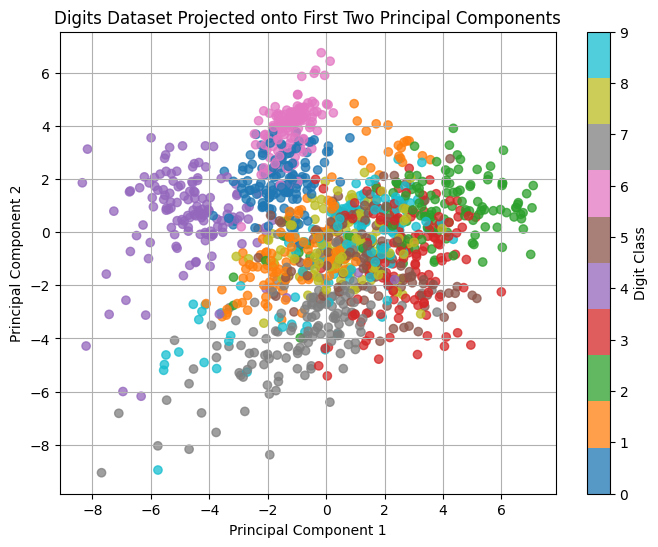

Explained variance ratio of PC1: 0.12155493372315786
Explained variance ratio of PC2: 0.09624944545687489
Total explained variance ratio of first two PCs: 0.21780437918003276


In [43]:
mean_2d, components_2d, _, explained_variance_ratio_2d = fit_pca(
    X_train_scaled,
    n_components=2
)

X_train_pca_2d = transform_pca(X_train_scaled, mean_2d, components_2d)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_train_pca_2d[:, 0],
    X_train_pca_2d[:, 1],
    c=y_train,
    cmap="tab10",
    alpha=0.75
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Digits Dataset Projected onto First Two Principal Components")
plt.colorbar(scatter, label="Digit Class")
plt.grid(True)
plt.show()

print("Explained variance ratio of PC1:", explained_variance_ratio_2d[0])
print("Explained variance ratio of PC2:", explained_variance_ratio_2d[1])
print("Total explained variance ratio of first two PCs:", explained_variance_ratio_2d.sum())

Two-Dimensional PCA Visualization

Inspect the 2D PCA scatter plot.

1. Are the digit classes clearly separable using only two principal components?
2. Which digit classes appear to overlap the most?
3. Why is PCA useful for visualization but not necessarily sufficient for classification?



**Answer 3:**
1-)No, the digit classes are not clearly separable using only two components. If you look at the center of the plot, most of the colors are mixed together in one big group. This means a computer would have a hard time telling them apart based only on this 2D information.

2-)The digits that overlap the most appear to be 3 (red), 5 (brown), and 9 (light blue). In the middle of the scatter plot, these colors are sitting right on top of each other, making them very difficult to distinguish.

3-)PCA is very useful for visualization because it allows us to project 64 different features into a simple 2D graph that humans can understand. However, it is not sufficient for classification because these two components only explain 21.7% of the total variance. Since we are losing nearly 80% of the data's information, the "clusters" aren't clean enough for a model to reach high accuracy.

## 8. Baseline Multiclass Classification Without PCA

Before using PCA, we first train a classifier on the original 64-dimensional standardized data.

We will use multinomial logistic regression.

**Points: 4**

In [44]:
baseline_clf = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_SEED
)

baseline_clf.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_clf.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average="macro")

print("Baseline accuracy:", baseline_accuracy)
print("Baseline macro F1-score:", baseline_macro_f1)

print("\nClassification report:")
print(classification_report(y_test, y_pred_baseline))

Baseline accuracy: 0.98
Baseline macro F1-score: 0.9801122608366214

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      0.98      0.99        46
           2       0.98      1.00      0.99        44
           3       1.00      0.96      0.98        46
           4       0.98      1.00      0.99        45
           5       1.00      0.91      0.95        46
           6       0.98      1.00      0.99        45
           7       0.96      0.96      0.96        45
           8       1.00      1.00      1.00        43
           9       0.92      1.00      0.96        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



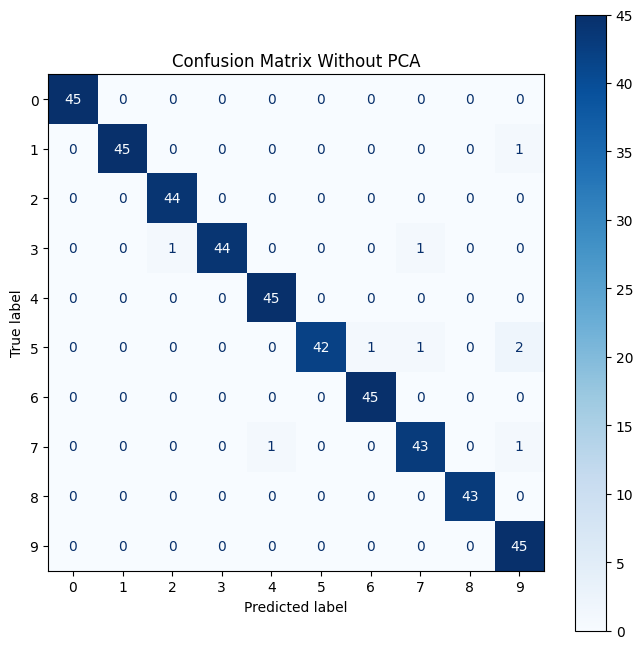

In [45]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=np.unique(y)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix Without PCA")
plt.show()

## 9. Multiclass Classification with PCA

Now we will train the same classifier after reducing the dimensionality using PCA.

You will evaluate different numbers of principal components.

**Points: 8**

In [56]:
component_list = [2, 5, 10, 15, 20, 30, 40, 50, 64]

pca_results = []

for n_comp in component_list:
    mean_n, components_n, _, explained_ratio_n = fit_pca(
        X_train_scaled,
        n_components=n_comp
    )

    X_train_pca_n = transform_pca(X_train_scaled, mean_n, components_n)
    X_test_pca_n = transform_pca(X_test_scaled, mean_n, components_n)

    clf = LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_SEED
    )

    clf.fit(X_train_pca_n, y_train)

    y_pred = clf.predict(X_test_pca_n)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    total_variance = explained_ratio_n.sum()

    pca_results.append({
        "n_components": n_comp,
        "explained_variance_ratio": total_variance,
        "accuracy": acc,
        "macro_f1": macro_f1
    })

pca_results

[{'n_components': 2,
  'explained_variance_ratio': np.float64(0.21780437918003276),
  'accuracy': 0.5111111111111111,
  'macro_f1': 0.49382960972902995},
 {'n_components': 5,
  'explained_variance_ratio': np.float64(0.4142003684391513),
  'accuracy': 0.8066666666666666,
  'macro_f1': 0.8049686793918605},
 {'n_components': 10,
  'explained_variance_ratio': np.float64(0.5890388602755268),
  'accuracy': 0.8888888888888888,
  'macro_f1': 0.8879688928762516},
 {'n_components': 15,
  'explained_variance_ratio': np.float64(0.7101723156376647),
  'accuracy': 0.9422222222222222,
  'macro_f1': 0.9415603545208272},
 {'n_components': 20,
  'explained_variance_ratio': np.float64(0.7947170449360492),
  'accuracy': 0.9577777777777777,
  'macro_f1': 0.9577779086983526},
 {'n_components': 30,
  'explained_variance_ratio': np.float64(0.8944961442568371),
  'accuracy': 0.96,
  'macro_f1': 0.95992101563302},
 {'n_components': 40,
  'explained_variance_ratio': np.float64(0.9510589931064599),
  'accuracy': 

In [55]:
print("n_components | explained_variance | accuracy | macro_f1")
print("-" * 65)

for result in pca_results:
    print(
        f"{result['n_components']:>12} | "
        f"{result['explained_variance_ratio']:.4f}             | "
        f"{result['accuracy']:.4f}   | "
        f"{result['macro_f1']:.4f}"
    )

n_components | explained_variance | accuracy | macro_f1
-----------------------------------------------------------------
           2 | 0.2178             | 0.5111   | 0.4938
           5 | 0.4142             | 0.8067   | 0.8050
          10 | 0.5890             | 0.8889   | 0.8880
          15 | 0.7102             | 0.9422   | 0.9416
          20 | 0.7947             | 0.9578   | 0.9578
          30 | 0.8945             | 0.9600   | 0.9599
          40 | 0.9511             | 0.9667   | 0.9667
          50 | 0.9829             | 0.9778   | 0.9779
          64 | 1.0000             | 0.9800   | 0.9801


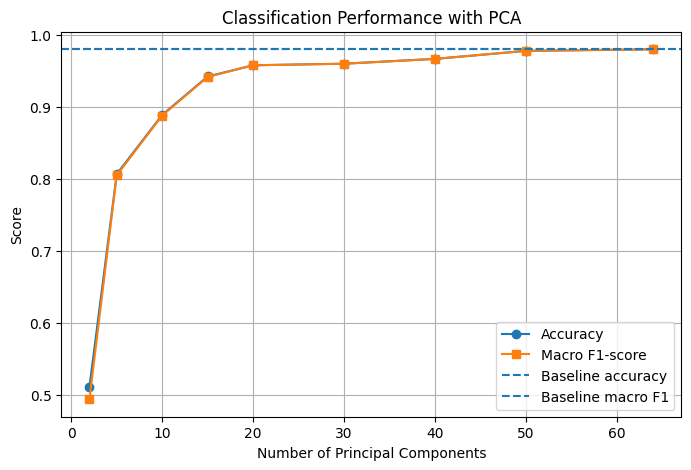

In [48]:
components_for_plot = [r["n_components"] for r in pca_results]
accuracies = [r["accuracy"] for r in pca_results]
macro_f1_scores = [r["macro_f1"] for r in pca_results]
explained_variances = [r["explained_variance_ratio"] for r in pca_results]

plt.figure(figsize=(8, 5))
plt.plot(components_for_plot, accuracies, marker="o", label="Accuracy")
plt.plot(components_for_plot, macro_f1_scores, marker="s", label="Macro F1-score")
plt.axhline(y=baseline_accuracy, linestyle="--", label="Baseline accuracy")
plt.axhline(y=baseline_macro_f1, linestyle="--", label="Baseline macro F1")
plt.xlabel("Number of Principal Components")
plt.ylabel("Score")
plt.title("Classification Performance with PCA")
plt.legend()
plt.grid(True)
plt.show()

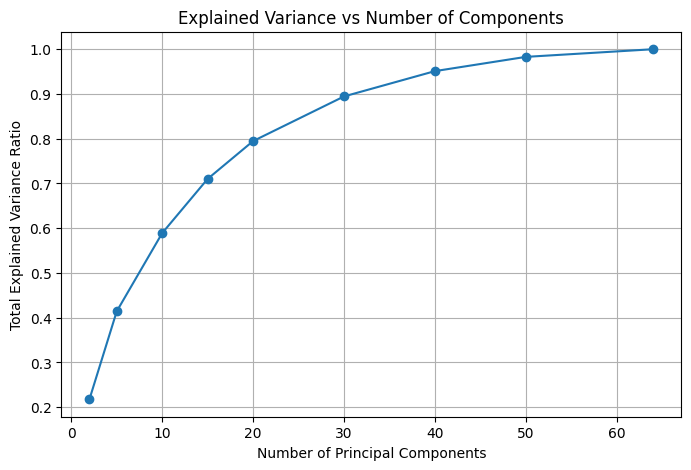

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(components_for_plot, explained_variances, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Total Explained Variance Ratio")
plt.title("Explained Variance vs Number of Components")
plt.grid(True)
plt.show()

### Implementation Task 4 — Automatic Component Selection

Complete the function below.

The goal is to find the smallest number of PCA components whose classification score is within a given tolerance of the baseline score.

For example, if the baseline accuracy is 0.96 and the tolerance is 0.02, then the PCA model should have accuracy at least 0.94.

**Points: 3**

In [51]:
def find_smallest_component_count(results, baseline_score, tolerance=0.02, metric="accuracy"):
    """
    Find the smallest number of PCA components whose classification score
    is within a given tolerance of the baseline score.

    Parameters
    ----------
    results : list of dict
        PCA evaluation results.
    baseline_score : float
        Baseline classification score without PCA.
    tolerance : float
        Allowed drop from the baseline score.
    metric : str
        Metric to compare. Example: "accuracy" or "macro_f1".

    Returns
    -------
    selected_result : dict or None
        Result dictionary for the selected number of components.
        Return None if no result satisfies the condition.
    """

    selected_result = None

    for result in results:
        # TODO: Check whether result[metric] is within tolerance of baseline_score
        # If yes, assign result to selected_result and stop the loop.
        if result[metric] >= (baseline_score - tolerance):
            selected_result = result
            break

    return selected_result

# ---------------------------------------------------------
# The testing code provided in the cell:

selected_by_accuracy = find_smallest_component_count(
    pca_results,
    baseline_accuracy,
    tolerance=0.02,
    metric="accuracy"
)

selected_by_macro_f1 = find_smallest_component_count(
    pca_results,
    baseline_macro_f1,
    tolerance=0.02,
    metric="macro_f1"
)

print("Smallest component count within 0.02 accuracy of baseline:")
print(selected_by_accuracy)

print("\nSmallest component count within 0.02 macro F1 of baseline:")
print(selected_by_macro_f1)

Smallest component count within 0.02 accuracy of baseline:
{'n_components': 30, 'explained_variance_ratio': np.float64(0.8944961442568371), 'accuracy': 0.96, 'macro_f1': 0.95992101563302}

Smallest component count within 0.02 macro F1 of baseline:
{'n_components': 40, 'explained_variance_ratio': np.float64(0.9510589931064599), 'accuracy': 0.9666666666666667, 'macro_f1': 0.9666603584276426}


## 10. Detailed Analysis for One PCA Configuration

Choose one PCA configuration for deeper analysis.

You should select a number of components that gives a reasonable balance between dimensionality reduction and classification performance.

For example, you may choose the smallest number of components that achieves near-baseline accuracy.

In [52]:
# TODO: Choose a number of components based on your previous results.
# You may use selected_by_accuracy or selected_by_macro_f1 to guide your choice.
chosen_n_components = 5

assert chosen_n_components is not None, "Please choose the number of components."

mean_chosen, components_chosen, _, explained_ratio_chosen = fit_pca(
    X_train_scaled,
    n_components=chosen_n_components
)

X_train_pca_chosen = transform_pca(X_train_scaled, mean_chosen, components_chosen)
X_test_pca_chosen = transform_pca(X_test_scaled, mean_chosen, components_chosen)

chosen_clf = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_SEED
)

chosen_clf.fit(X_train_pca_chosen, y_train)

y_pred_chosen = chosen_clf.predict(X_test_pca_chosen)

chosen_accuracy = accuracy_score(y_test, y_pred_chosen)
chosen_macro_f1 = f1_score(y_test, y_pred_chosen, average="macro")

print("Chosen number of components:", chosen_n_components)
print("Explained variance ratio:", explained_ratio_chosen.sum())
print("Accuracy:", chosen_accuracy)
print("Macro F1-score:", chosen_macro_f1)

print("\nClassification report:")
print(classification_report(y_test, y_pred_chosen))

Chosen number of components: 5
Explained variance ratio: 0.4142003684391513
Accuracy: 0.8066666666666666
Macro F1-score: 0.8049686793918605

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        45
           1       0.78      0.85      0.81        46
           2       0.85      0.77      0.81        44
           3       0.69      0.74      0.72        46
           4       0.94      1.00      0.97        45
           5       0.93      0.80      0.86        46
           6       0.93      0.96      0.95        45
           7       0.71      0.80      0.75        45
           8       0.58      0.49      0.53        43
           9       0.68      0.76      0.72        45

    accuracy                           0.81       450
   macro avg       0.81      0.81      0.80       450
weighted avg       0.81      0.81      0.81       450



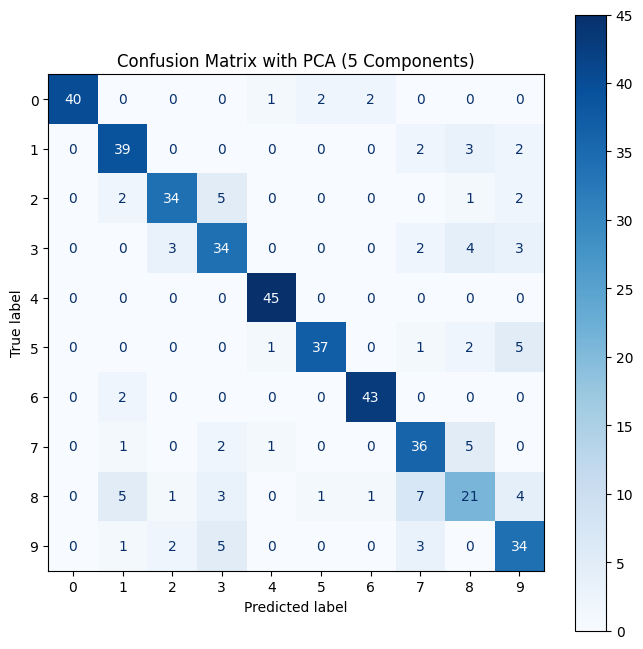

In [53]:
cm_chosen = confusion_matrix(y_test, y_pred_chosen)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_chosen,
    display_labels=np.unique(y)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix with PCA ({chosen_n_components} Components)")
plt.show()

— PCA and Multiclass Classification

Compare the baseline classifier with the PCA-based classifiers.

1. What are the baseline accuracy and macro F1-score without PCA?
2. How do accuracy and macro F1-score change as the number of PCA components increases?
3. What is the smallest number of components that gives performance close to the baseline?
4. Which classes are most frequently confused in the baseline and PCA models?
5. Would you recommend using PCA before classification for this dataset? Justify your answer using your results.



**Answer 4:**
1-)The baseline classifier without PCA performs very well. It has an accuracy of 0.98 and a macro F1-score of 0.9801. This means the model is nearly perfect when using all 64 original features.

2-)As the number of PCA components increases, both accuracy and the macro F1-score rise significantly. With only 2 components, the accuracy is very low (0.5111). However, it jumps to 0.8889 at 10 components and keeps improving until it levels off near the baseline.

3-)If we want performance close to the baseline (within 0.02), the smallest number of components needed is 30 components to match baseline accuracy (0.9600) and 40 components to match the baseline macro F1-score (0.9667).

4-)In the baseline model (without PCA), there are very few mistakes because the model uses all the information. The most confusion happens between digit 5 and digit 9. According to the matrix, digit 5 was wrongly predicted as digit 9 two times. Other small mistakes happened with digit 3, which was confused with digit 2 and digit 7 one time each.
In the PCA model (with 5 components), the confusion is much higher because the images become blurry. The most confused class is digit 8. It was correctly predicted only 21 times out of 43. It was frequently mistaken for digit 7 (7 times), digit 1 (5 times), and digit 3 (3 times). Also, digit 3 was often confused with digit 8 (4 times). This shows that when we reduce the dimensions too much, digits with similar shapes like 8, 1, and 7 start to look the same to the model.

5-)Yes, I would recommend using PCA for this dataset, especially if we choose between 30 and 40 components.Based on the numerical evidence, using 40 components provides an accuracy of 0.9667, which is very close to the baseline accuracy of 0.98. This means we can remove 24 unnecessary features and still get almost the same results. Reducing the dimensions makes the model faster and saves memory, which is very important if the dataset grows larger. However, I would not recommend using a very low number like 5 components, because the accuracy falls significantly to 0.8067. In summary, PCA is excellent for efficiency as long as we keep enough components to stay within $2\%$ of the original performance.


## 11. Final Conceptual Summary

Answer the following question carefully.

Your answer should be written in your own words.

Final Conceptual Summary

**Answer 5:**
PCA (Principal Component Analysis) is a tool that helps us simplify complex data. In this assignment, we used it to turn 64 pixels into a smaller number of principal components. The main goal was to see the trade-off between making the data smaller (dimensionality reduction) and keeping it accurate (information loss). We found that if we reduce the data too much, like using only 5 components, the accuracy drops to 0.81 because the images become too blurry to distinguish similar digits like 8, 1, and 7. However, by using 40 components, we kept 95% of the variance and achieved an accuracy of 0.9667, which is almost as good as our 0.98 baseline performance.

We also learned that PCA is used differently depending on the goal. For visualization, we use 2 or 3 components to see the data on a 2D or 3D graph, even though we lose about 78% of the information. For classification, we need more components to keep the model accurate. A major limitation of PCA is that it is unsupervised, meaning it only looks for the "loudest" patterns (variance) and might ignore the tiny details that help separate specific classes. Overall, PCA was very useful because it proved we can reduce the data size by nearly 40% while maintaining excellent results, making our machine learning models much more efficient.
